<a href="https://colab.research.google.com/github/VictorBlainn/Library_Independent_Regression_VS_Scikit-learn/blob/main/Parkinsons_Telemonitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [21]:
data_matrix = np.loadtxt('parkinsons_updrs.data', delimiter=',', skiprows=1)
print(data_matrix.shape)


(5875, 22)
5875


This particular dataset consists of 19 features and two target variables. Now we are going to extract the target variables into separate 1D numpy vectors.

In [ ]:
target_variables_1 = data_matrix[:,4]
target_variables_2 = data_matrix[:,5]


Let's delete the target Variables column from data_matrix as well as the patients id column and create a new feature matrix for our regression model

In [ ]:
col_remove = np.delete(data_matrix,[0,4,5], axis =1 )
feature_matrix = col_remove
print(feature_matrix.shape)


(5875, 19)


Let's visualize the dataset and its features. The goal is to visualize the distribution of each feature against the target variable. This dataset has two target varibles , and for now we will work with 'total_UPDRS' which is stored in target_variables_2



In [ ]:
df = pd.read_csv('parkinsons_updrs.data')
names = list(df.columns)
names.remove('total_UPDRS')
names.remove('motor_UPDRS')
names.remove('subject#')
feature_name = names #feature names has been extracted in a list for x axis labels


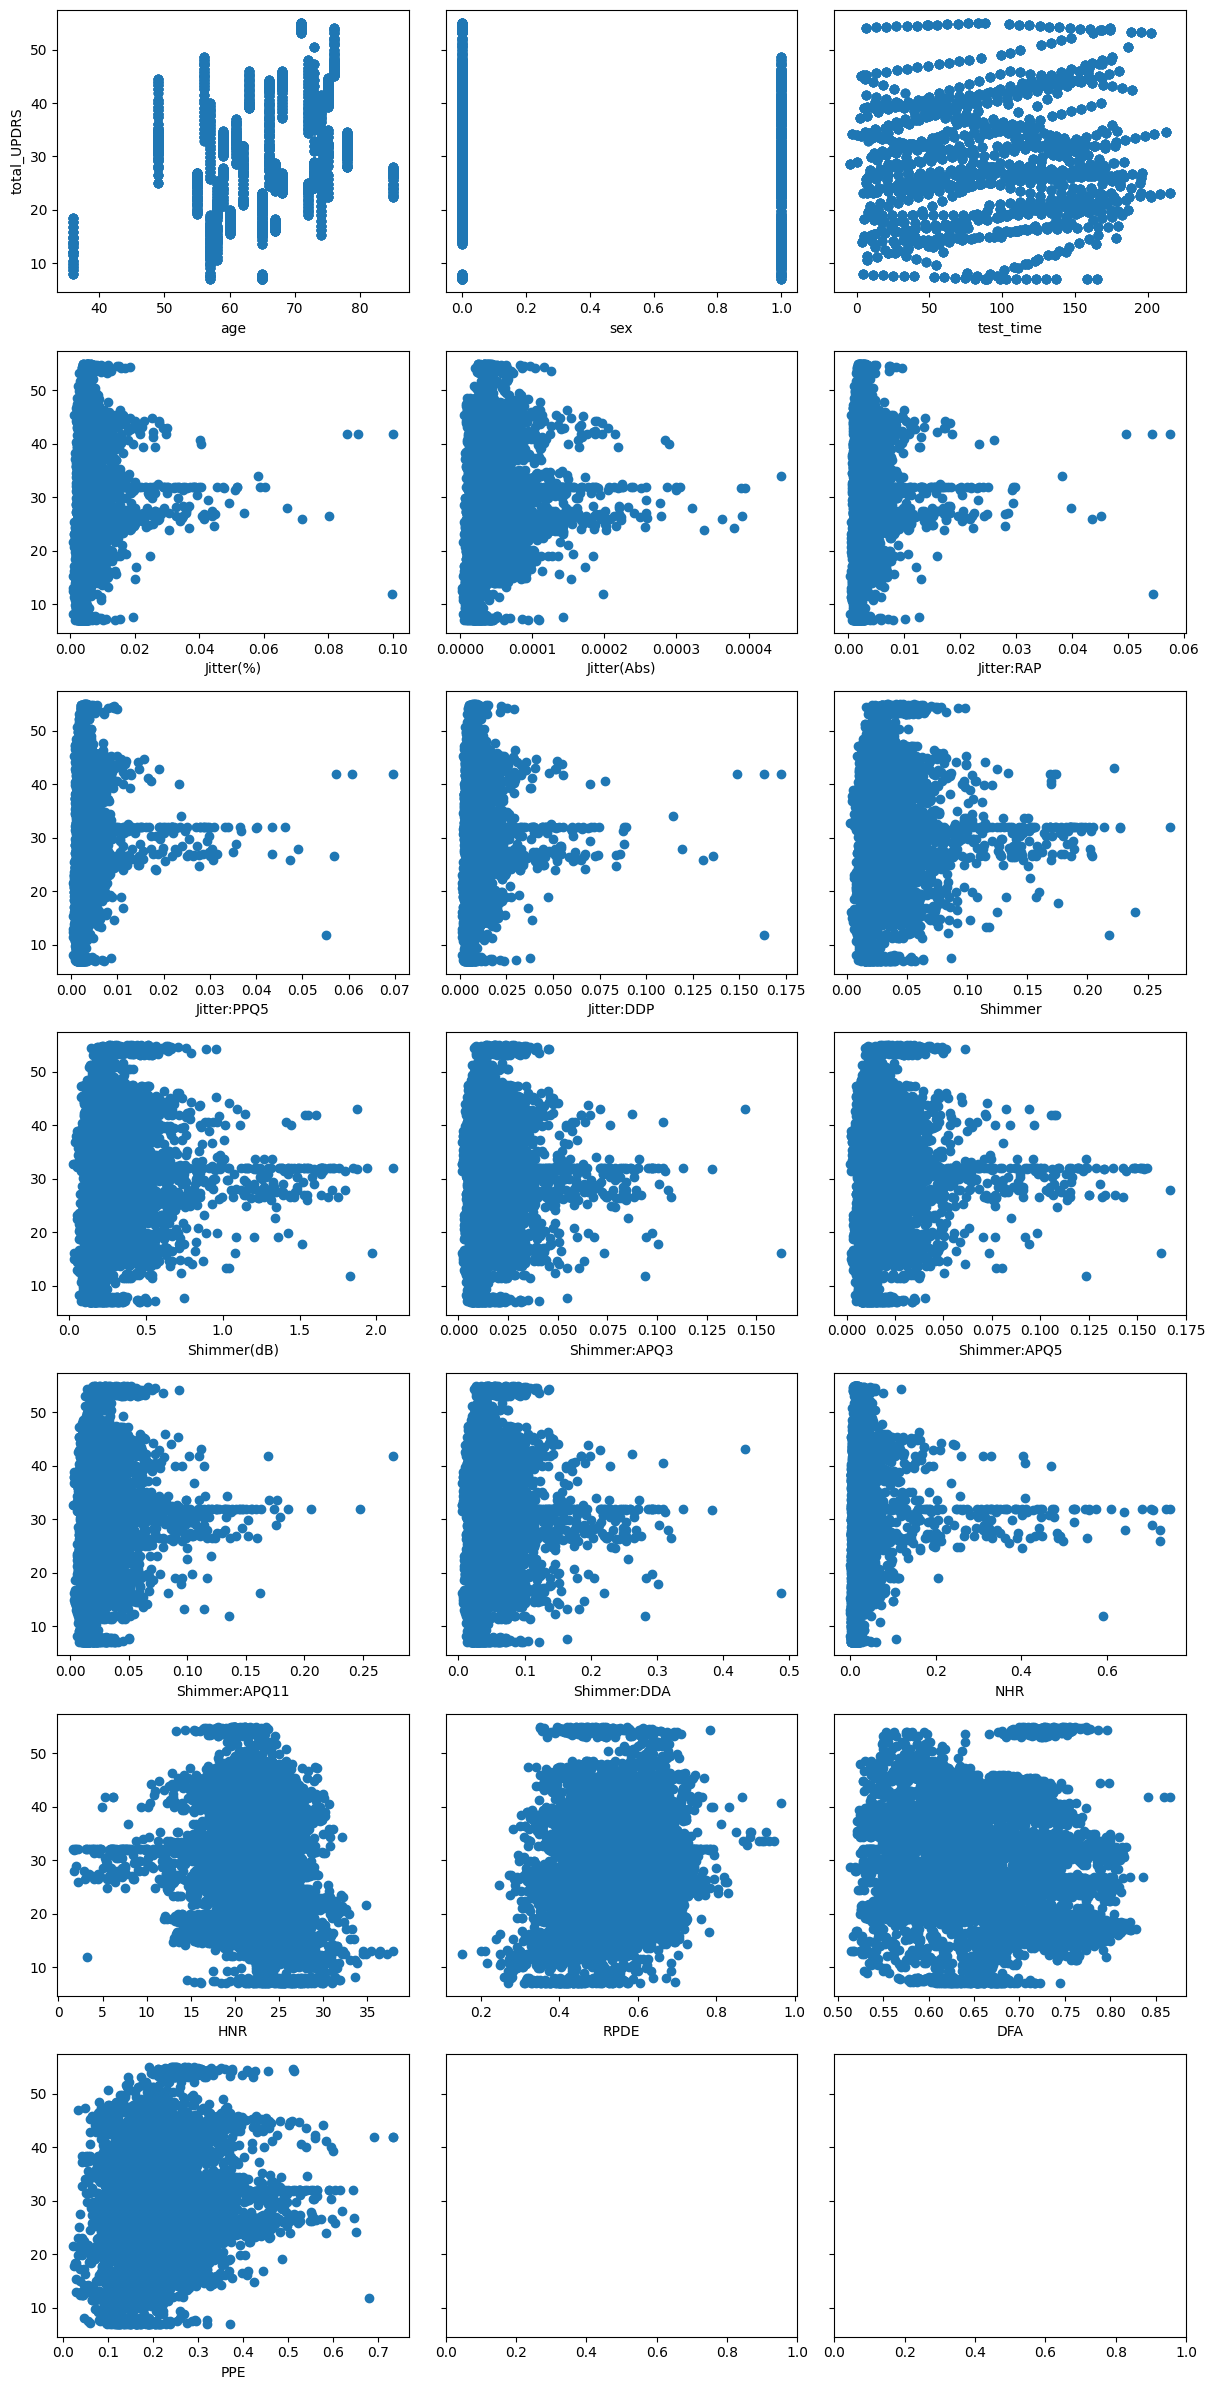

In [ ]:
fig, fig_matrix= plt.subplots(7,3, figsize= (12,24) , sharey=True)
placeholder = fig_matrix.flatten()
num_features= 19
for i in range(num_features):
    if i < len(placeholder):
        placeholder[i].scatter(feature_matrix[:,i],target_variables_2)
        placeholder[i].set_xlabel(feature_name[i])


plt.tight_layout()



placeholder[0].set_ylabel('total_UPDRS')
plt.show()

# Feature Scalling
let's determine if the dataset needs rescaling

In [ ]:
def check_scaling(matrix):
    variance_dataset = np.var(matrix, axis=0)

    peak_to_peak = np.ptp(matrix, axis=0)

    print(f'Variance of features by column: {variance_dataset}')
    print(f'Peak to peak range by column: {peak_to_peak}')

check_scaling(feature_matrix)

Variance of features by column: [7.78060352e+01 2.16798508e-01 2.85594618e+03 3.16265595e-05
 1.29458171e-09 9.75658404e-06 1.39219939e-05 8.78098837e-05
 6.67341772e-04 5.30077252e-02 1.75191459e-04 2.77639393e-04
 3.99378018e-04 1.57672628e-03 3.56256485e-03 1.84103729e+01
 1.01963934e-02 5.02623732e-03 8.37054938e-03]
Peak to peak range by column: [4.900000e+01 1.000000e+00 2.197525e+02 9.916000e-02 4.433400e-04
 5.721000e-02 6.913000e-02 1.716500e-01 2.655700e-01 2.081000e+00
 1.610600e-01 1.650800e-01 2.729700e-01 4.831800e-01 7.479740e-01
 3.621600e+01 8.150600e-01 3.515600e-01 7.097470e-01]


Because the variances and peak-to-peak ranges of the features differ drastically from one another, we will standardize the dataset using Z-score normalization. Let's create a function for that.

In [ ]:
def zscore_normalization(matrix):
    mean_feature = np.mean(matrix, axis=0)
    std_feature = np.std(matrix, axis=0)
    normalized_features = (matrix - mean_feature) / std_feature
    return normalized_features

check_scaling(zscore_normalization(feature_matrix))

Variance of features by column: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Peak to peak range by column: [ 5.55506874  2.14769129  4.11205405 17.63236401 12.32174407 18.31568024
 18.52745797 18.31774913 10.28027799  9.03862767 12.16833703  9.90726814
 13.6591238  12.16832487 12.53155927  8.44051971  8.07172372  4.95881562
  7.75758574]


In [ ]:
def mean_normalization(matrix):
    mean_feature=np.mean(matrix, axis=0)
    feature_ptp = np.ptp(matrix, axis=0)

    normalized_features = (matrix - mean_feature)/(feature_ptp)
    return normalized_features

check_scaling(mean_normalization(feature_matrix))

Variance of features by column: [0.03240568 0.21679851 0.05914014 0.00321647 0.00658651 0.00298094
 0.00291319 0.00298027 0.00946216 0.01224038 0.00675363 0.01018808
 0.00535987 0.00675365 0.00636781 0.01403659 0.01534855 0.04066718
 0.01661678]
Peak to peak range by column: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [23]:
normalized_features = zscore_normalization(feature_matrix)

# The Regression Model
The primary function that will be used in this regression model is f(**w,x**) = 𝐰⃗ · 𝐱⃗ + b,
where 𝐰⃗ and 𝐱⃗ are n-dimensional vectors, where n = number of features, and b is a scalar bias term.
However, the model won't be strictly limited to linear regression. First, we will evaluate how well the model is doing through evaluating the costs after parameter tuning and cross validation dataset. Then, higher order terms (polynomial) may be introduced by feature engineering to capture the non-linear relationship, if there is any.

# Mean squared Cost function without regulaization
As there are two different target variables, we will train two different models instead of a 'Multivariate Regression. Let's create a cost function for the target varibel 'total UPDRS'. A separate cost function with regulization parameter will be created later two comapre the two instance.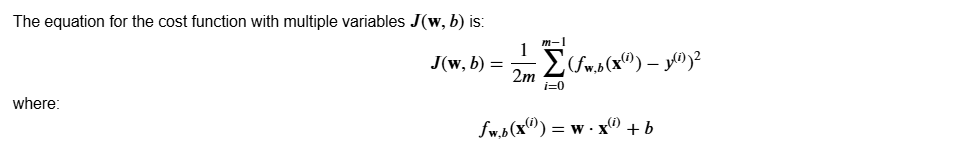

In [79]:
def cost_function(w, b, features, target):
  m = features.shape[0]
  f_wb = np.dot(features, w) + b
  cost = np.sum((f_wb - target)**2) / (2*m)
  return cost

In [80]:
n=normalized_features.shape[1]

w= np.random.randn(n)
b= 2
features = normalized_features
target = target_variables_2
print(cost_function(w,b,features,target))

420.88375807118933


# Parameter Tuning through Gradient Descent
Given a cost function J(w, b), we need to find the values of w and b that minimize J(w, b). This is achieved through an algorithm called gradient descent, which uses the partial derivatives of the cost function with respect to w and b.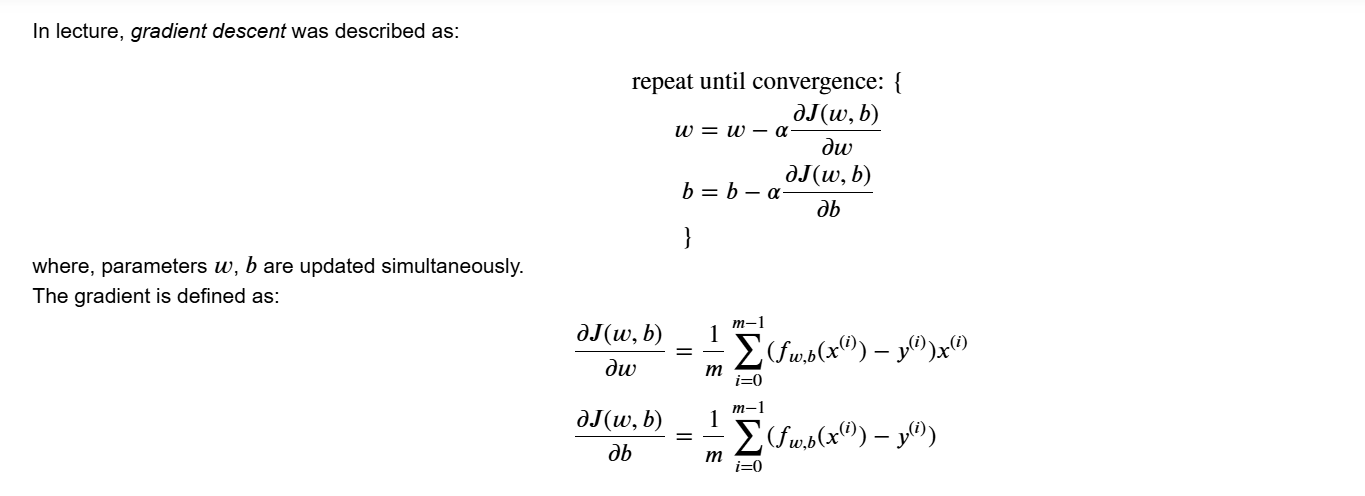

In [81]:
def derivatives(w, b, features, target):
    m = features.shape[0]
    f_wb = np.dot(features, w) + b
    error = f_wb - target
    dj_dw = np.dot(features.T, error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

In [82]:
def gradient_descent(w, b, features, target, learning_rate, iterations):
    for i in range(iterations):
        dj_dw, dj_db = derivatives(w, b, features, target)
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db
    return w, b

# Visualizing how  Gradient descent minimize the cost function overtime through history of updated cost function and 'cost function vs iteration' graph

In [83]:
def visualize_GD(w_in, b_in, features, target, learning_rate, iterations):
    cost_history = []
    w = w_in
    b = b_in
    for i in range(iterations):
        dj_dw, dj_db = derivatives(w, b, features, target)
        w = w - learning_rate*dj_dw
        b = b - learning_rate*dj_db
        if i < 100000:
            cost_history.append(cost_function(w, b, features, target))
        #we will only print the cost_history at intervals of ten time and the last most one, for readability
        if i % math.ceil(iterations/10) == 0 or i == (iterations-1):
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f}   ")

    fig, (graph1, graph2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
    graph1.plot(cost_history[:100])
    graph2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
    graph1.set_title("Cost vs. iteration(start)");  graph2.set_title("Cost vs. iteration (end)")
    graph1.set_ylabel('Cost')                    ;  graph2.set_ylabel('Cost')
    graph1.set_xlabel('iteration step')           ;  graph2.set_xlabel('iteration step')
    plt.show()

Iteration    0: Cost   474.46   
Iteration 10000: Cost    47.17   
Iteration 20000: Cost    47.15   
Iteration 30000: Cost    47.14   
Iteration 40000: Cost    47.14   
Iteration 50000: Cost    47.14   
Iteration 60000: Cost    47.14   
Iteration 70000: Cost    47.14   
Iteration 80000: Cost    47.14   
Iteration 90000: Cost    47.14   
Iteration 99999: Cost    47.14   


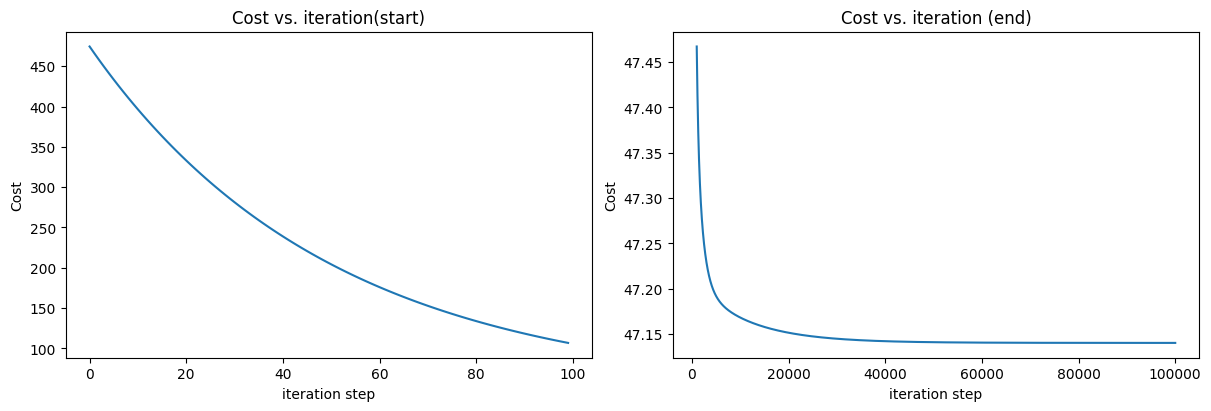

In [85]:
features = normalized_features
target = target_variables_2
m,n = features.shape
w_in = np.random.randn(n)
b_in = 0
iterations = 100000
learning_rate = 0.01
visualize_GD(w_in, b_in, features, target, learning_rate, iterations)